# Meshing

This notebook is used to develop the meshing tools necessary for this project. The components of this task are as follows.

- Efficiently read in a fort.14 file
- Filter the mesh to the sub-region of interest.
- Preserve boundary segments for use in the FEniCSx solver.

In [1]:
import basix.ufl
import dolfinx as dx
import dolfinx.plot
from mpi4py import MPI
import numpy as np
import matplotlib.tri
import pyvista as pv
import scipy.interpolate
import scipy.spatial
import ufl

## Read in fort.14

In [2]:
with open('120m_cut.14', 'r') as f:
    # Read name
    name = f.readline()

    # Read element/node metadata
    NE, NP = np.loadtxt(f, dtype=int, max_rows=1, usecols=(0, 1)) # Number of elements, nodes
    print(f'mesh name: {name}\nNE = {NE}, NP = {NP}')

    # Read node data
    dat = np.loadtxt(f, dtype=float, max_rows=NP, usecols=(0, 1, 2, 3))
    JN = dat[:, 0].astype(int)
    XY = dat[:, 1:3]
    X = dat[:, 1]
    Y = dat[:, 2]
    DP = dat[:, 3]
    print(f'Read node data of shape {dat.shape}')

    # Read element data
    dat = np.loadtxt(f, dtype=int, max_rows=NE, usecols=(0, 1, 2, 3, 4))
    JE = dat[:, 0]
    # Ignore NHY for now
    NM = dat[:, 2:5]
    print(f'Read element data of shape {dat.shape}')

    # Read elevation boundary metadata
    NOPE = np.loadtxt(f, dtype=int, max_rows=1, usecols=0) # Number of elevation segments
    NETA = np.loadtxt(f, dtype=int, max_rows=1, usecols=0) # Number of elevation nodes

    # Read elevation boundary data
    NVDLL = [] # Number of nodes in each elevation segment
    IBTYPEE = [] # Elevation bonudary segment type
    NBDV = [] # Node numbers for each elevation segment
    for k in range(NOPE):
        NVDLLK = np.loadtxt(f, dtype=int, max_rows=1, usecols=0)
        IBTYPEEK = 0 # Only accepted value
        NBDVK = np.loadtxt(f, dtype=int, max_rows=NVDLLK, usecols=0)
        NVDLL.append(NVDLLK)
        IBTYPEE.append(IBTYPEEK)
        NBDV.append(NBDVK)
        print(f'Read segment k = {k + 1} of type IBTYPEE(k) = {IBTYPEEK} and shape NBDV(k) = {NBDVK.shape} = {NVDLLK}')
    print(f'Read NOPE = {NOPE} segments with NETA = {NETA} total nodes')

    # Read velocity boundary metadata
    NBOU = np.loadtxt(f, dtype=int, max_rows=1, usecols=0) # Number of normal flow segments
    NVEL = np.loadtxt(f, dtype=int, max_rows=1, usecols=0) # Number of normal flow nodes
    
    # Read velocity boundary data
    NVELL = [] # Number of nodes in each segment
    IBTYPE = [] # Velocity boundary segment type
    NBVV = [] # Node numbers for each elevation segment
    # Additional data for different boundary types
    BARLANHT = []
    BARLANCFSP = []
    IBCONN = []
    BARINHT = []
    BARINCFSB = []
    BARINCFSP = []
    PIPEHT = []
    PIPECOEF = []
    PIPEDIAM = []
    for k in range(NBOU):
        NVELLK, IBTYPEK = np.loadtxt(f, dtype=int, max_rows=1, usecols=(0, 1))
        if IBTYPEK in [0, 1, 2, 10, 11, 12, 20, 21, 22, 30]:
            NBVVK = np.loadtxt(f, dtype=int, max_rows=NVELLK, usecols=0)
            BARLANHTK = None
            BARLANCFSPK = None
            IBCONNK = None
            BARINHTK = None
            BARINCFSBK = None
            BARINCFSPK = None
            PIPEHTK = None
            PIPECOEFK = None
            PIPEDIAMK = None
        elif IBTYPEK in [3, 13, 23]:
            dat = np.loadtxt(f, dtype=float, max_rows=NVELLK, usecols=(0, 1, 2))
            NBVVK = dat[:, 0].astype(int)
            BARLANHTK = dat[:, 1]
            BARLANCFSPK = dat[:, 2]
            IBCONNK = None
            BARINHTK = None
            BARINCFSBK = None
            BARINCFSPK = None
            PIPEHTK = None
            PIPECOEFK = None
            PIPEDIAMK = None
        elif IBTYPEK in [4, 24]:
            dat = np.loadtxt(f, dtype=float, max_rows=NVELLK, usecols=(0, 1, 2, 3, 4))
            NBVVK = dat[:, 0].astype(int)
            BARLANHTK = None
            BARLANCFSPK = None
            IBCONNK = dat[:, 1].astype(int)
            BARINHTK = dat[:, 2]
            BARINCFSBK = dat[:, 3]
            BARINCFSPK = dat[:, 4]
            PIPEHTK = None
            PIPECOEFK = None
            PIPEDIAMK = None
        elif IBTYPEK in [5, 25]:
            dat = np.loadtxt(f, dtype=float, max_rows=NVELLK, usecols=(0, 1, 2, 3, 4, 5, 6, 7))
            NBVVK = dat[:, 0].astype(int)
            BARLANHTK = None
            BARLANCFSPK = None
            IBCONNK = dat[:, 1].astype(int)
            BARINHTK = dat[:, 2]
            BARINCFSBK = dat[:, 3]
            BARINCFSPK = dat[:, 4]
            PIPEHTK = dat[:, 5]
            PIPECOEFK = dat[:, 6]
            PIPEDIAMK = dat[:, 7]
        NVELL.append(NVELLK)
        IBTYPE.append(IBTYPEK)
        NBVV.append(NBVVK)
        BARLANHT.append(BARLANHTK)
        BARLANCFSP.append(BARLANCFSPK)
        IBCONN.append(IBCONNK)
        BARINHT.append(BARINHTK)
        BARINCFSB.append(BARINCFSBK)
        BARINCFSP.append(BARINCFSPK)
        PIPEHT.append(PIPEHTK)
        PIPECOEF.append(PIPECOEFK)
        PIPEDIAM.append(PIPEDIAMK)
        print(f'Read segment k = {k + 1} of type IBTYPE(k) = {IBTYPEK} and shape NBVV(k) = {NBVVK.shape} = {NVELLK}')
    print(f'Read NBOU = {NBOU} segments with NVEL = {NVEL} total nodes')

mesh name: OceanMesh2D

NE = 3832707, NP = 1947485
Read node data of shape (1947485, 4)
Read element data of shape (3832707, 5)
Read segment k = 1 of type IBTYPEE(k) = 0 and shape NBDV(k) = (146,) = 146
Read NOPE = 1 segments with NETA = 146 total nodes
Read segment k = 1 of type IBTYPE(k) = 24 and shape NBVV(k) = (37,) = 37
Read segment k = 2 of type IBTYPE(k) = 24 and shape NBVV(k) = (69,) = 69
Read segment k = 3 of type IBTYPE(k) = 24 and shape NBVV(k) = (33,) = 33
Read segment k = 4 of type IBTYPE(k) = 24 and shape NBVV(k) = (47,) = 47
Read segment k = 5 of type IBTYPE(k) = 24 and shape NBVV(k) = (9,) = 9
Read segment k = 6 of type IBTYPE(k) = 24 and shape NBVV(k) = (47,) = 47
Read segment k = 7 of type IBTYPE(k) = 24 and shape NBVV(k) = (13,) = 13
Read segment k = 8 of type IBTYPE(k) = 24 and shape NBVV(k) = (16,) = 16
Read segment k = 9 of type IBTYPE(k) = 24 and shape NBVV(k) = (45,) = 45
Read segment k = 10 of type IBTYPE(k) = 24 and shape NBVV(k) = (49,) = 49
Read segment k = 

## Create mesh

Crucially, note that ADCIRC uses 1-based while Python/FEniCSx use 0-based indexing/

In [3]:
# Define simple triangular-type mesh
ufl_tri = ufl.Mesh(basix.ufl.element('Lagrange', 'triangle', 1, shape=(2,)))

In [4]:
# Create mesh from element specification and coordinates
domain = dx.mesh.create_mesh(MPI.COMM_WORLD, cells=NM - 1, x=XY, e=ufl_tri)

## Visualization

In [5]:
V = dx.fem.functionspace(domain, ('Lagrange', 1))
dp = dx.fem.Function(V)

In [6]:
original_coordinate_indices = domain.geometry.input_global_indices # (processor) local index -> input index (ADCIRC offset by 1)
dofmap = V.dofmap
vertex_to_dof = dofmap.index_map.local_to_global(np.arange(dofmap.index_map.size_local, dtype=np.int32))

# Get coordinates of each DOF
dof_coords = V.tabulate_dof_coordinates()[:dofmap.index_map.size_local]
tree = scipy.spatial.cKDTree(XY)
# Find which index of your original XY matches each DOF coordinate
_, original_indices_for_dofs = tree.query(dof_coords[:, :2], k=1)

In [7]:
# Fill in dp
dp.x.array[:dofmap.index_map.size_local] = DP[original_indices_for_dofs]
dp.x.scatter_forward()

In [8]:
topology, cell_types, geometry = dx.plot.vtk_mesh(V)
grid = pv.UnstructuredGrid(topology, cell_types, geometry)
grid.point_data['dp'] = dp.x.array.real

/var/folders/nc/8r3mn3bn43b7lyftplq0rtrc0000gn/T/ipykernel_14071/1582341319.py:10: UserWarning: Using static image for notebook display.
Install trame for interactive backends: pip install "pyvista[jupyter]"
  plotter.show()


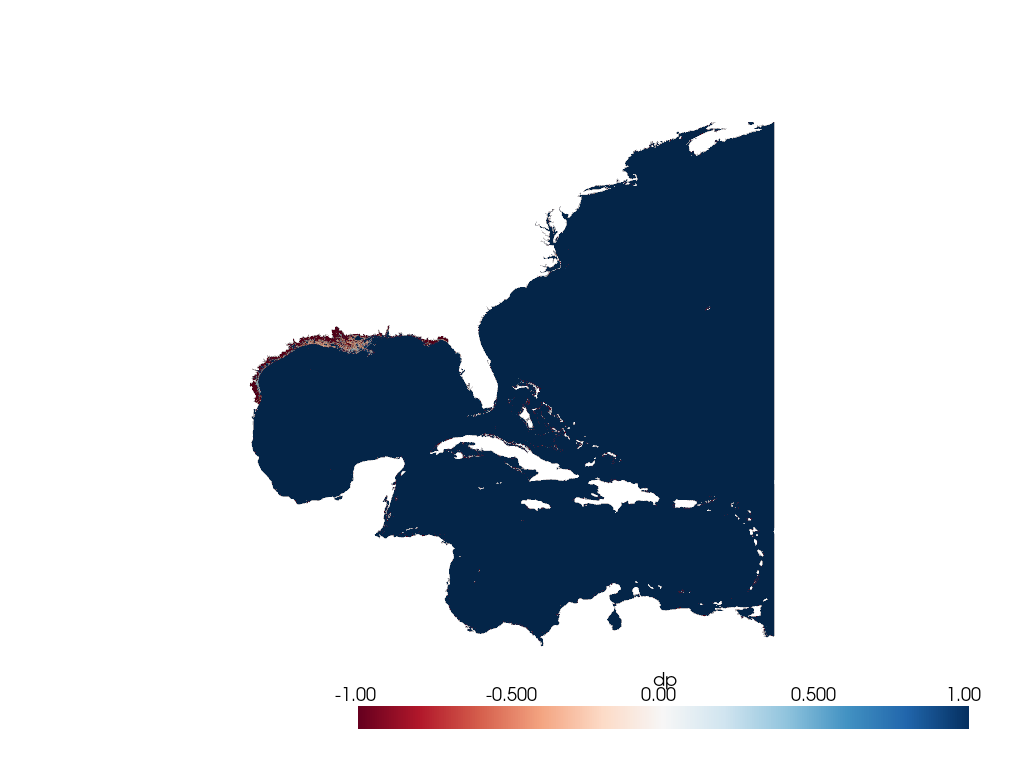

In [9]:
plotter = pv.Plotter()
plotter.add_mesh(
    grid,
    scalars='dp',
    cmap='RdBu',
    clim=[-1.0, 1.0],
    show_edges=False
)
plotter.view_xy()
plotter.show()

## Filter to the subregion of interest

In [10]:
# The center of a circular filter
# Location of Port Aransas
pa_lon = -97.0611 # deg
pa_lat = 27.8339 # deg

In [11]:
# The radius of the circular mesh filter
# Expressed as arc length on a sphere
arcradius_km = 10.0 # km
radius_earth = 6371.0 # km
# arcradius_rad = arcradius_km / radius_earth
# arcradius_deg = np.rad2deg(arcradius_rad)

In [12]:
def central_angle(lon1, lat1, lon2, lat2, use_deg = True):
    """Compute the central angle between two points on a sphere, given longitude and latitude.

    This is computed from the haversine fomula.

    hav(theta) = hav(lat2 - lat1) + cos(lat1) * cos(lat2) * hav(lon2 - lon1)

    Let a = hav(theta). Then a numerically stable way to compute theta exploits arctangent.

    theta = atan2()

    Arguments:
        lon1 (float): The longitude of the first point.
        lat1 (float): The latitude of the first point.
        lon2 (float): The longitude of the second point.
        lat2 (float): The latitude of the second point.
        use_deg (bool, optional): Whether the inputs are provided in degrees. If True, the output will also be converted to degrees. Default is True.

    Returns:
        float: The central angle between the two points on a sphere, in the same units as the inputs.
    """
    # Ensure computations are in radians
    if use_deg:
        lon1 = np.deg2rad(lon1)
        lat1 = np.deg2rad(lat1)
        lon2 = np.deg2rad(lon2)
        lat2 = np.deg2rad(lat2)

    # Compute haversine of theta
    a = np.sin((lat2 - lat1) / 2.0) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin((lon2 - lon1) / 2.0) ** 2

    # Compute theta
    theta = 2 * np.atan2(np.sqrt(a), np.sqrt(1 - a))

    # Convert back to the user's units
    if use_deg:
        theta = np.rad2deg(theta)
    return theta

In [13]:
# First, create a filter for nodes in this range
node_filter = np.deg2rad(central_angle(pa_lon, pa_lat, X, Y, use_deg=True)) * radius_earth < arcradius_km
print(f'Filtered down to {int(np.sum(node_filter))} nodes')

Filtered down to 5278 nodes


In [14]:
# Second, create a filter for elements in this range
# Elements must have all of their nodes within the radius
element_filter = node_filter[NM[:, 0] - 1] & node_filter[NM[:, 1] - 1] & node_filter[NM[:, 2] - 1]
print(f'Filtered down to {int(np.sum(element_filter))} elements')

Filtered down to 10382 elements


In [15]:
# Select nodes
# Create a FEniCSx-friendly indexing
coordinates_filtered = XY[node_filter]
node_filter_map = np.cumsum(node_filter) - 1 # Maps from Python index of nodes to new filtered mesh
node_filter_map[~node_filter] = -1 # If not in the mesh, set to -1
node_filter_map

array([-1, -1, -1, ..., -1, -1, -1], shape=(1947485,))

In [16]:
# Select elements
# Use Python 0 convention
elements_filtered = NM[element_filter] - 1 # Fix ADCIRC 1-index
elements_filtered

array([[1277204, 1267142, 1267143],
       [1267141, 1267143, 1256936],
       [1267142, 1256936, 1267143],
       ...,
       [1296752, 1287121, 1296751],
       [1296751, 1306012, 1306014],
       [1296752, 1296751, 1306014]], shape=(10382, 3))

In [17]:
# Renumber to a local index
elements_filtered = node_filter_map[elements_filtered] # Renumber
elements_filtered

array([[4026, 3863, 3864],
       [3862, 3864, 3699],
       [3863, 3699, 3864],
       ...,
       [4332, 4182, 4331],
       [4331, 4473, 4475],
       [4332, 4331, 4475]], shape=(10382, 3))

In [18]:
element_filter_map = np.cumsum(element_filter) - 1 # Maps from Python index of nodes to new filtered mesh
element_filter_map[~element_filter] = -1 # If not in the mesh, set to -1

In [19]:
# Get reverse arrays
# np.nonzero() returns an index array of all nonzero (True) indices
reverse_node_filter_map = np.nonzero(node_filter)
reverse_node_filter_map

(array([ 833880,  833907,  833908, ..., 1391100, 1391102, 1397637],
       shape=(5278,)),)

In [20]:
reverse_element_filter_map = np.nonzero(element_filter)
reverse_element_filter_map

(array([ 279444,  279445,  279446, ..., 3643566, 3643567, 3643568],
       shape=(10382,)),)

## Create mesh

Crucially, note that ADCIRC uses 1-based while Python/FEniCSx use 0-based indexing/

In [21]:
# Define simple triangular-type mesh
ufl_tri = ufl.Mesh(basix.ufl.element('Lagrange', 'triangle', 1, shape=(2,)))

In [22]:
# Create mesh from element specification and coordinates
domain = dx.mesh.create_mesh(MPI.COMM_WORLD, cells=elements_filtered, x=coordinates_filtered, e=ufl_tri)

## Visualization

In [23]:
# To assign nodal collocation values like bathymetry, fort.xx.nc outputs
# Construct a linear interpolator
# Instead of messing around with degrees of freetdom
triangulation = matplotlib.tri.Triangulation(coordinates_filtered[:, 0], coordinates_filtered[:, 1], elements_filtered)
bathymetry_interpolator = matplotlib.tri.LinearTriInterpolator(triangulation, DP[node_filter])

In [24]:
def bathymetry_interpolator_wrapper(x):
    return bathymetry_interpolator(x[0], x[1])

In [25]:
V = dx.fem.functionspace(domain, ('Lagrange', 1))
dp = dx.fem.Function(V)
dp.interpolate(bathymetry_interpolator_wrapper)

In [26]:
topology, cell_types, geometry = dx.plot.vtk_mesh(V)
grid = pv.UnstructuredGrid(topology, cell_types, geometry)
grid.point_data['dp'] = dp.x.array.real

/var/folders/nc/8r3mn3bn43b7lyftplq0rtrc0000gn/T/ipykernel_14071/2540066378.py:10: UserWarning: Using static image for notebook display.
Install trame for interactive backends: pip install "pyvista[jupyter]"
  plotter.show()


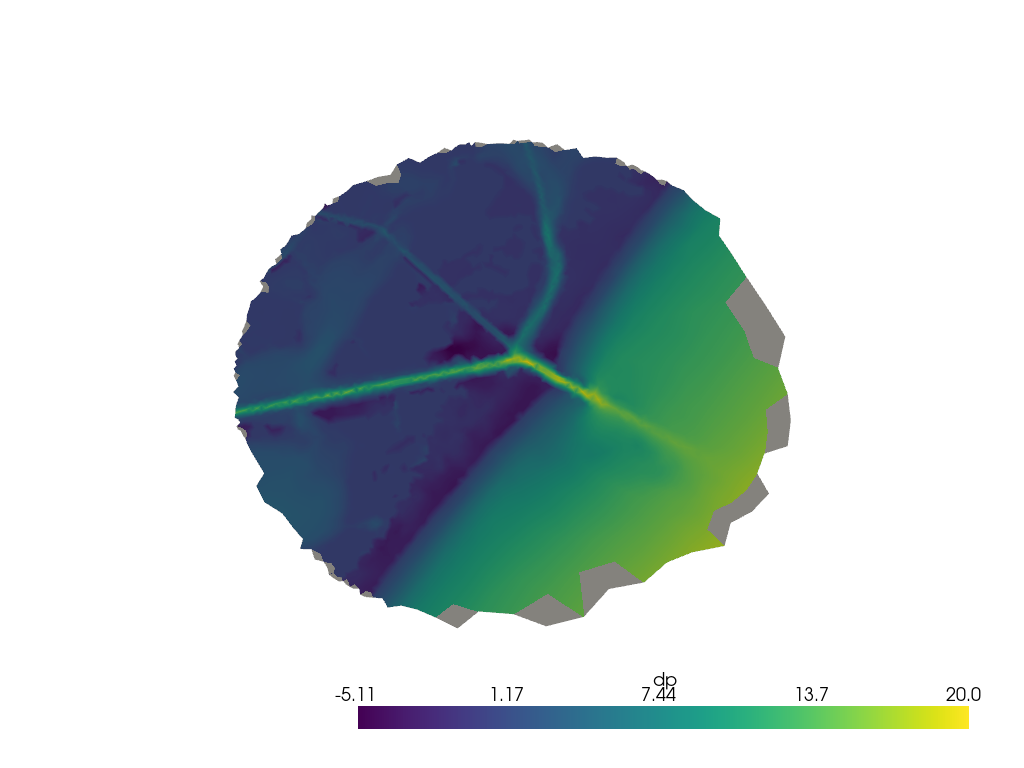

In [27]:
plotter = pv.Plotter()
plotter.add_mesh(
    grid,
    #scalars='dp',
    #cmap='RdBu',
    #clim=[-1.0, 1.0],
    show_edges=False
)
plotter.view_xy()
plotter.show()